In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load ds_salary csv file using pandas


In [21]:
data = pd.read_csv("ds_salaries.csv")

In [22]:
data

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [23]:
data.columns

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='str')

In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [25]:
data.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [26]:
data.drop("Unnamed: 0", axis=1, inplace=True)

In [27]:
data.duplicated().sum()

np.int64(42)

In [29]:
data.drop_duplicates(inplace=True)

In [30]:
data.duplicated().sum()


np.int64(0)

In [31]:
data.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [33]:
data['experience_level'].value_counts()


experience_level
SE    243
MI    208
EN     88
EX     26
Name: count, dtype: int64

In [34]:
data['employment_type'].value_counts()


employment_type
FT    546
PT     10
CT      5
FL      4
Name: count, dtype: int64

In [35]:
data['company_size'].value_counts()

company_size
M    290
L    193
S     82
Name: count, dtype: int64

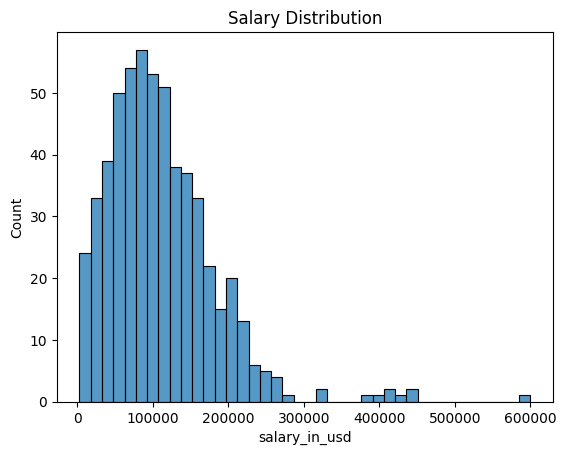

In [40]:
sns.histplot(data['salary_in_usd'], bins=40)
plt.title("Salary Distribution")
plt.show()

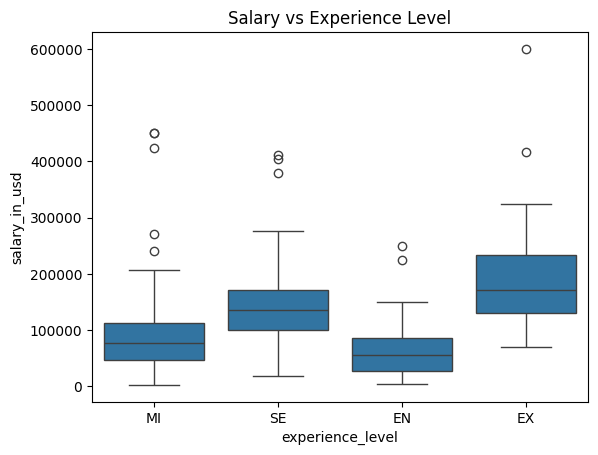

In [41]:
sns.boxplot(x='experience_level', y='salary_in_usd', data=data)
plt.title("Salary vs Experience Level")
plt.show()

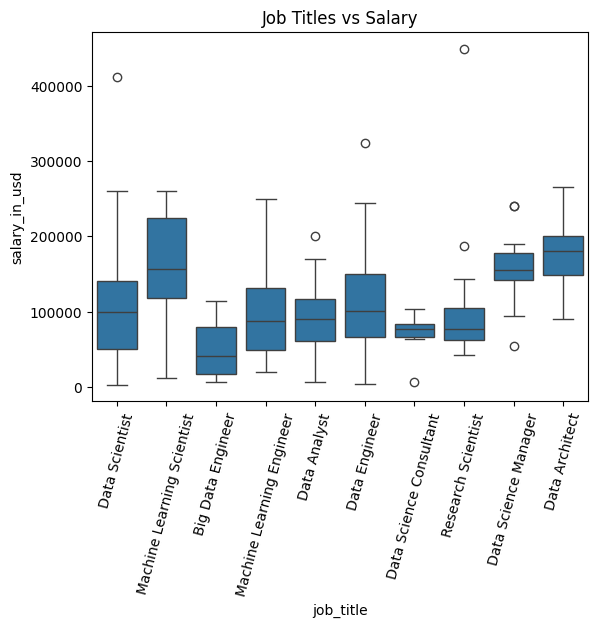

In [45]:
jobs = data['job_title'].value_counts().head(10).index
sns.boxplot(data=data[data['job_title'].isin(jobs)],x='job_title', y='salary_in_usd')

plt.xticks(rotation=75)
plt.title("Job Titles vs Salary")
plt.show()

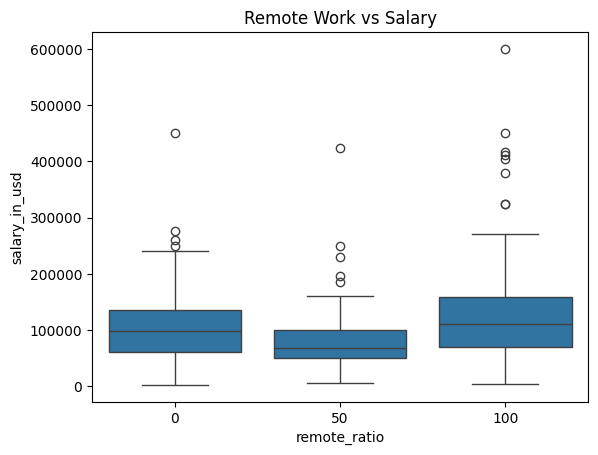

In [47]:
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=data)
plt.title("Remote Work vs Salary")
plt.show()

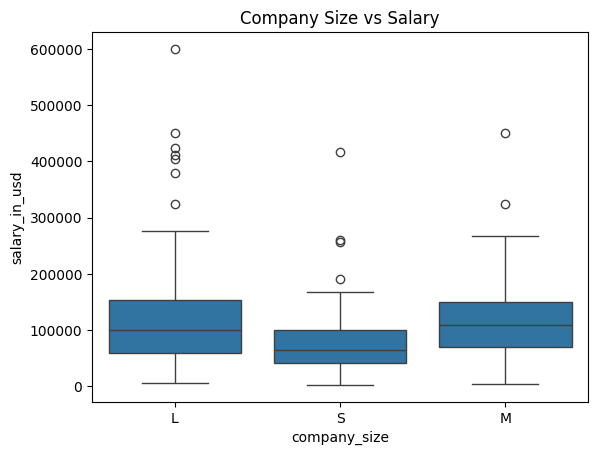

In [48]:
sns.boxplot(x='company_size', y='salary_in_usd', data=data)
plt.title("Company Size vs Salary")
plt.show()

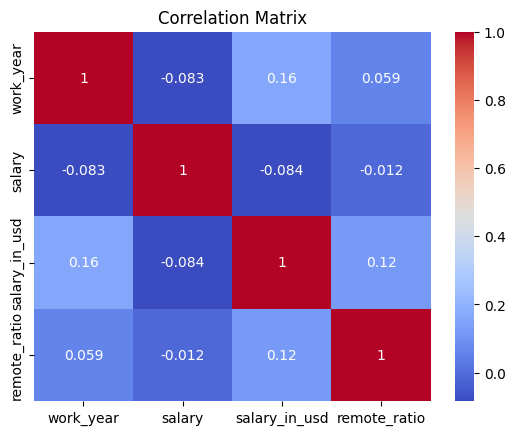

In [50]:

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

(array([2019.75, 2020.  , 2020.25, 2020.5 , 2020.75, 2021.  , 2021.25,
        2021.5 , 2021.75, 2022.  , 2022.25]),
 [Text(2019.75, 0, '2019.75'),
  Text(2020.0, 0, '2020.00'),
  Text(2020.25, 0, '2020.25'),
  Text(2020.5, 0, '2020.50'),
  Text(2020.75, 0, '2020.75'),
  Text(2021.0, 0, '2021.00'),
  Text(2021.25, 0, '2021.25'),
  Text(2021.5, 0, '2021.50'),
  Text(2021.75, 0, '2021.75'),
  Text(2022.0, 0, '2022.00'),
  Text(2022.25, 0, '2022.25')])

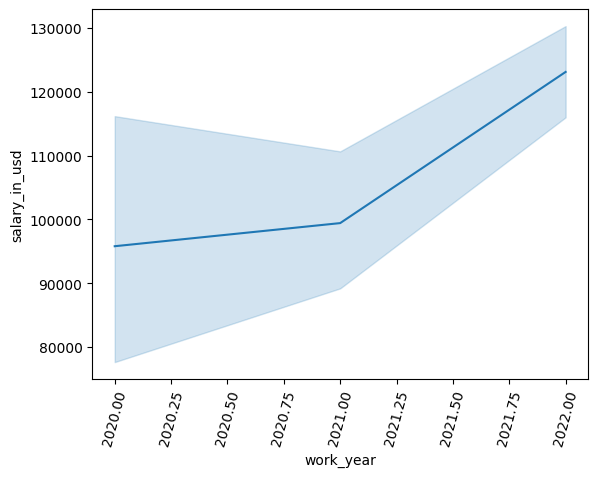

In [52]:
sns.lineplot(x="work_year", y="salary_in_usd", data=data)
plt.xticks(rotation=75)